In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nih-chest-xrays/sample")
print("Path to dataset files:", path)


# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

100%|██████████| 4.20G/4.20G [03:23<00:00, 22.1MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/nih-chest-xrays/sample/versions/4


In [3]:
import os
import torch
import numpy as np
import pandas as pd
import torchvision.models as models
import torchvision.transforms as trns
from torchvision.datasets import ImageFolder
from torchvision.transforms import ToTensor
from torch.utils.data import random_split, DataLoader, Dataset
import matplotlib.pyplot as plt
from PIL import Image

%matplotlib inline
plt.rcParams['figure.figsize'] = [8, 10]

In [4]:
import os
dataset_path=path
file_map = {}

# Assuming the images are directly in the dataset_path:
image_dir = dataset_path

# If the images are in a subfolder, adjust the path accordingly:
# image_dir = os.path.join(dataset_path, "images")

for f in os.listdir(image_dir):
    if f.endswith('.png'):  # Ensure only image files are included
        file_map[f] = os.path.join(image_dir, f)

print("Total images loaded:", len(file_map))

Total images loaded: 0


In [5]:
# # file_map = dict()
# # for i in range(12):
# #     path = '/kaggle/input/data/images_' + ('00' if i < 9 else '0') + str(i + 1) + '/images/'
# #     for f in os.listdir(path):
# #         if os.path.isfile(os.path.join(path, f)) and f[-4:] == '.png':
# #             file_map[f] = os.path.join(path, f)
# import os
# dataset_path=path
# file_map = {}
# image_dir = os.path.join(dataset_path, "images")  # Adjust based on dataset structure

# for f in os.listdir(image_dir):
#     if f.endswith('.png'):  # Ensure only image files are included
#         file_map[f] = os.path.join(image_dir, f)

# print("Total images loaded:", len(file_map))
import os
import shutil

# Define source and destination paths
source_path = "/root/.cache/kagglehub/datasets/nih-chest-xrays"
destination_path = "/kaggle/working/nih-chest-xrays"  # Change to your preferred location

# Copy entire dataset folder
if os.path.exists(destination_path):
    print("Destination folder already exists, skipping copy.")
else:
    shutil.copytree(source_path, destination_path)
    print(f"Dataset copied to: {destination_path}")




Dataset copied to: /kaggle/working/nih-chest-xrays


In [6]:
# Now update dataset_path to use the copied data
dataset_path = '/kaggle/working/nih-chest-xrays/sample/versions/4/sample'
image_dir = os.path.join(dataset_path, "images")  # Adjust based on dataset structure

# Load images
file_map = {}
if os.path.exists(image_dir):
    for f in os.listdir(image_dir):
        if f.endswith('.png'):
            file_map[f] = os.path.join(image_dir, f)
    print("Total images loaded:", len(file_map))
else:
    print("Warning: 'images' directory not found! Check dataset structure.")

Total images loaded: 5606


In [7]:
import os
for root, dirs, files in os.walk(dataset_path):
    print(root)
    for file in files[:5]:  # Print first 5 files for each directory
        print("  ", file)


/kaggle/working/nih-chest-xrays/sample/versions/4/sample
   sample_labels.csv
/kaggle/working/nih-chest-xrays/sample/versions/4/sample/images
   00008415_000.png
   00006413_002.png
   00022526_006.png
   00012774_000.png
   00003343_000.png
/kaggle/working/nih-chest-xrays/sample/versions/4/sample/sample
/kaggle/working/nih-chest-xrays/sample/versions/4/sample/sample/images
   00008415_000.png
   00006413_002.png
   00022526_006.png
   00012774_000.png
   00003343_000.png


In [8]:
import os

path = "/kaggle/working/nih-chest-xrays/sample/versions/4"

if os.path.exists(path):
    print("Contents of:", path)
    for item in os.listdir(path):
        print(" -", item)
else:
    print("Path does not exist!")


Contents of: /kaggle/working/nih-chest-xrays/sample/versions/4
 - sample_labels.csv
 - sample


In [9]:
# df = pd.read_csv('/kaggle/input/data/Data_Entry_2017.csv')
# df.head(10)
dataset_path='/kaggle/working/nih-chest-xrays/sample/versions/4'
csv_path = os.path.join(dataset_path, "sample_labels.csv")  # Adjust based on dataset structure
df = pd.read_csv(csv_path)
df.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImageWidth,OriginalImageHeight,OriginalImagePixelSpacing_x,OriginalImagePixelSpacing_y
0,00000013_005.png,Emphysema|Infiltration|Pleural_Thickening|Pneu...,5,13,060Y,M,AP,3056,2544,0.139,0.139
1,00000013_026.png,Cardiomegaly|Emphysema,26,13,057Y,M,AP,2500,2048,0.168,0.168
2,00000017_001.png,No Finding,1,17,077Y,M,AP,2500,2048,0.168,0.168
3,00000030_001.png,Atelectasis,1,30,079Y,M,PA,2992,2991,0.143,0.143
4,00000032_001.png,Cardiomegaly|Edema|Effusion,1,32,055Y,F,AP,2500,2048,0.168,0.168


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5606 entries, 0 to 5605
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Image Index                  5606 non-null   object 
 1   Finding Labels               5606 non-null   object 
 2   Follow-up #                  5606 non-null   int64  
 3   Patient ID                   5606 non-null   int64  
 4   Patient Age                  5606 non-null   object 
 5   Patient Gender               5606 non-null   object 
 6   View Position                5606 non-null   object 
 7   OriginalImageWidth           5606 non-null   int64  
 8   OriginalImageHeight          5606 non-null   int64  
 9   OriginalImagePixelSpacing_x  5606 non-null   float64
 10  OriginalImagePixelSpacing_y  5606 non-null   float64
dtypes: float64(2), int64(4), object(5)
memory usage: 481.9+ KB


In [11]:
def showImage(pil):
    plt.imshow(np.array(pil) / 255)

In [12]:
def loadImage(path):
    return Image.open(path).convert('RGB')

In [13]:
print("Total images found:", len(file_map))


Total images found: 5606


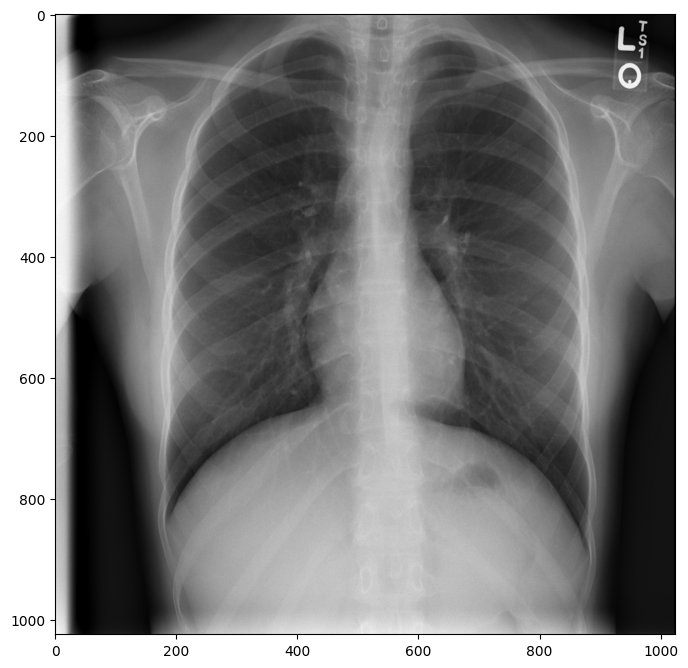

In [14]:
showImage(loadImage(file_map[list(file_map.keys())[100]]))

In [15]:
classes = [
    'Atelectasis',
    'Consolidation',
    'Infiltration',
    'Pneumothorax',
    'Edema',
    'Emphysema',
    'Fibrosis',
    'Effusion',
    'Pneumonia',
    'Pleural_thickening',
    'Cardiomegaly',
    'Nodule',
    'Mass',
    'Hernia',
    'No Finding'
]

In [16]:
class ImageDataset(Dataset):
    def __init__(self, data, transforms):
        self.image_paths = [file_map[f] for f in data[0]]
        self.labels = data[1]
        self.transforms = transforms

    def __len__(self):
        return len(data[0])

    def __getitem__(self, idx):
        image = self.transforms(loadImage(self.image_paths[idx]))
        target = torch.tensor([int(cls in self.labels[idx]) for cls in classes], dtype=torch.float32)
        return (image, target)

In [17]:
data = (df.iloc[:5000, 0], [df.iloc[i, 1].split('|') for i in range(5000)])

In [18]:
dataset = ImageDataset(data, trns.Compose([
    trns.Resize((240, 240)),
    trns.ToTensor(),
    trns.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225],inplace=True)
]))

tensor([0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0., 0.])


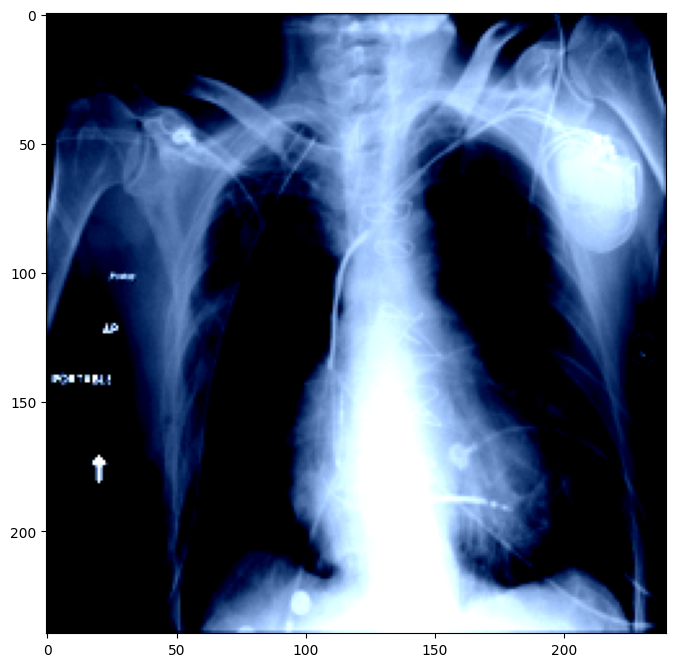

In [19]:
print(dataset[1][1])
plt.imshow(dataset[1][0].permute((1, 2, 0)))

In [20]:
train_dataset, validation_dataset = random_split(dataset, [int(len(dataset) * 0.85),
            len(dataset) - int(len(dataset) * 0.85)])

In [21]:
train_dataset_size = len(train_dataset)
validation_dataset_size = len(validation_dataset)

train_dataset_size, validation_dataset_size

(4250, 750)

Define notebook constants

In [22]:
num_classes = 15
input_shape = (3, 240, 240)

In [23]:
num_clients = 3
rounds = 10
batch_size = 64
epochs_per_client = 2
learning_rate = 1e-1

In [24]:
resnet34 = models.resnet34(pretrained=True)
resnet34

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth
100%|██████████| 83.3M/83.3M [00:00<00:00, 108MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [25]:
def get_device():
    return torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

def to_device(data, device):
    if isinstance(data, (list, tuple)):
        return [to_device(x, device) for x in data]
    return data.to(device, non_blocking=True)

class DeviceDataLoader(DataLoader):
        def __init__(self, dl, device):
            self.dl = dl
            self.device = device

        def __iter__(self):
            for batch in self.dl:
                yield to_device(batch, self.device)

        def __len__(self):
            return len(self.dl)

device = get_device()

**Define Federated Learnning Nettwork class**

In [26]:
class FederatedNet(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.network = models.resnet34(pretrained=True)
        self.network.fc = torch.nn.Linear(self.network.fc.in_features, num_classes)
        self.track_layers = {
            'layer4':  self.network.layer4,
            'linear': self.network.fc
        }
        self.freeze()

    def freeze(self):
        for param in self.network.parameters():
            param.requires_grad = False
        for layer_name in self.track_layers:
            for param in self.track_layers[layer_name].parameters():
                param.requires_grad = True

    def forward(self, x_batch):
        out = torch.sigmoid(self.network(x_batch))
        return out

    def get_track_layers(self):
        return self.track_layers

    def apply_parameters(self, parameters_dict):
        with torch.no_grad():
            for layer_name in parameters_dict:
                layer_params = list(self.track_layers[layer_name].parameters())
                for i in range(len(layer_params)):
                    layer_params[i].data = (layer_params[i].data + (parameters_dict[layer_name][i] -
                                                layer_params[i].data))

    def get_parameters(self):
        parameters_dict = dict()
        for layer_name in self.track_layers:
            parameters_dict[layer_name] = [param.data.clone().detach() for param in self.track_layers
                                                [layer_name].parameters()]
        return parameters_dict

    def batch_accuracy(self, outputs, labels):
        with torch.no_grad():
            return torch.tensor(torch.sum((outputs > 0.5) == labels).item() / len(outputs))
    def _process_batch(self, batch):
        images, labels = batch
        outputs = self(images)
        loss = torch.nn.functional.binary_cross_entropy(outputs, labels)
        accuracy = self.batch_accuracy(outputs, labels)
        return (loss, accuracy)

    def fit(self, dataset, epochs, lr, batch_size=128, opt=torch.optim.SGD):
        self.train()
        dataloader = DeviceDataLoader(DataLoader(dataset, batch_size, shuffle=True), device)
        optimizer = opt(self.parameters(), lr)
        history = []
        for epoch in range(epochs):
            losses = []
            accs = []
            for batch in dataloader:
                loss, acc = self._process_batch(batch)
                loss.backward()
                optimizer.step()
                optimizer.zero_grad()
                loss.detach()
                losses.append(loss)
                accs.append(acc)
            avg_loss = torch.stack(losses).mean().item()
            avg_acc = torch.stack(accs).mean().item()
            history.append((avg_loss, avg_acc))
        return history

    def evaluate(self, dataset, batch_size=64):
        self.eval()
        dataloader = DeviceDataLoader(DataLoader(dataset, batch_size), device)
        losses = []
        accs = []
        with torch.no_grad():
            for batch in dataloader:
                loss, acc = self._process_batch(batch)
                losses.append(loss)
                accs.append(acc)
        avg_loss = torch.stack(losses).mean().item()
        avg_acc = torch.stack(accs).mean().item()
        return (avg_loss, avg_acc)

**Define Client class****

In [27]:
class Client:
    def __init__(self, client_id, dataset):
        self.client_id = client_id
        self.dataset = dataset

    def get_dataset_size(self):
        return len(self.dataset)

    def get_client_id(self):
        return self.client_id

    def train(self, parameters_dict, return_model_dict=False):
        net = to_device(FederatedNet(), device)
        net.apply_parameters(parameters_dict)
        train_history = net.fit(self.dataset, epochs_per_client, learning_rate, batch_size)
        print(self.client_id + ':')
        for i, res in enumerate(train_history):
            print('Epoch [{}]: Loss = {}, Accuracy = {}'.format(i + 1, round(res[0], 4), round(res[1], 4)))
        return net.get_parameters(), net.state_dict() if return_model_dict else None

**set up for clients **

In [28]:
examples_per_client = train_dataset_size // num_clients
client_datasets = random_split(train_dataset, [min(i + examples_per_client,
           train_dataset_size) - i for i in range(0, train_dataset_size, examples_per_client)])
clients = [Client('client_' + str(i), client_datasets[i]) for i in range(num_clients)]

***Start Server ***********

In [29]:
global_net =
 (FederatedNet(), device)
history = []

for i in range(rounds):
    print('Start Round {} ...'.format(i + 1))
    curr_parameters = global_net.get_parameters()
    new_parameters = dict([(layer_name, [0 for param in global_net.track_layers[layer_name].parameters()])
                            for layer_name in curr_parameters])
    for j, client in enumerate(clients):
        client_parameters, state_dict = client.train(curr_parameters, (j == len(clients) - 1))
        if j == len(clients) - 1:
            global_net.load_state_dict(state_dict)
            global_net.apply_parameters(client_parameters)
            train_loss, train_acc = global_net.evaluate(train_dataset)
            val_loss, val_acc = global_net.evaluate(validation_dataset)
            print('After round {}, train_loss = {}, val_loss = {}, val_acc = {}\n'.format(i + 1, round(train_loss, 4),
                    round(val_loss, 4), round(val_acc, 4)))
            history.append((train_loss, val_loss))

        fraction = client.get_dataset_size() / train_dataset_size
        for layer_name in client_parameters:
            for j in range(len(client_parameters[layer_name])):
                new_parameters[layer_name][j] += fraction * client_parameters[layer_name][j]

    global_net.apply_parameters(new_parameters)

Start Round 1 ...
client_0:
Epoch [1]: Loss = 0.2398, Accuracy = 13.6556
Epoch [2]: Loss = 0.1911, Accuracy = 14.0122
client_1:
Epoch [1]: Loss = 0.2424, Accuracy = 13.6073
Epoch [2]: Loss = 0.198, Accuracy = 13.9728
client_2:
Epoch [1]: Loss = 0.2406, Accuracy = 13.6318
Epoch [2]: Loss = 0.1889, Accuracy = 14.0231
After round 1, train_loss = 0.1983, val_loss = 0.2046, val_acc = 13.903

Start Round 2 ...
client_0:
Epoch [1]: Loss = 0.1908, Accuracy = 14.002
Epoch [2]: Loss = 0.1828, Accuracy = 14.0489
client_1:
Epoch [1]: Loss = 0.1945, Accuracy = 13.966
Epoch [2]: Loss = 0.1906, Accuracy = 13.9905
client_2:
Epoch [1]: Loss = 0.1929, Accuracy = 14.0082
Epoch [2]: Loss = 0.1815, Accuracy = 14.0333
After round 2, train_loss = 0.1914, val_loss = 0.2, val_acc = 13.9588

Start Round 3 ...
client_0:
Epoch [1]: Loss = 0.1819, Accuracy = 14.0401
Epoch [2]: Loss = 0.181, Accuracy = 14.0299
client_1:
Epoch [1]: Loss = 0.1915, Accuracy = 13.9701
Epoch [2]: Loss = 0.1803, Accuracy = 14.0163
client

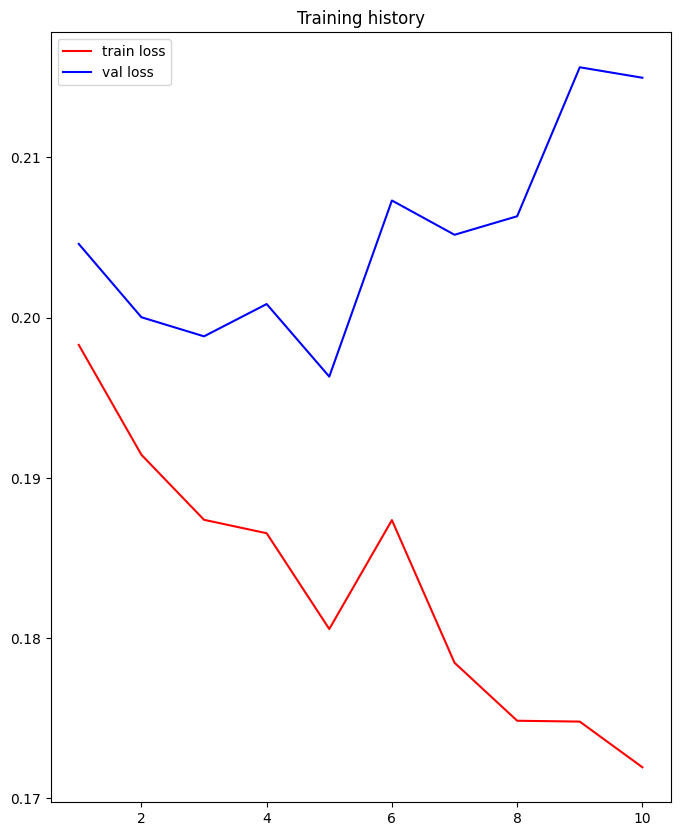

In [30]:
plt.plot([i + 1 for i in range(len(history))], [history[i][0] for i in range(len(history))], color='r', label='train loss')
plt.plot([i + 1 for i in range(len(history))], [history[i][1] for i in range(len(history))], color='b', label='val loss')
plt.title('Training history')
plt.legend()
plt.show()